# Dataset Inspection: Euclid, DESI, and Combined

This notebook inspects three astronomical datasets: Euclid, DESI, and Euclid+DESI combined.

## Imports

In [12]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

## 1. Euclid Dataset

In [13]:
dataset_euclid = load_dataset('parquet', data_dir='../data/astroPT_euclid_dataset/data', split='train')
print(f'Total samples: {len(dataset_euclid)}')

sample = dataset_euclid[0]
data = []
for key, value in sample.items():
    if hasattr(value, '__array__') or isinstance(value, (list, np.ndarray)):
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': str(np.array(value).shape)})
    else:
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': 'scalar'})

df = pd.DataFrame(data)
df

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Total samples: 10000


,Column,Type,Shape
0,object_id,int,scalar
1,RGB_image,PngImageFile,scalar
2,VIS_image,list,"(224, 224)"
3,NISP_Y_image,list,"(224, 224)"
4,NISP_J_image,list,"(224, 224)"
5,NISP_H_image,list,"(224, 224)"
6,SED,list,"(13,)"


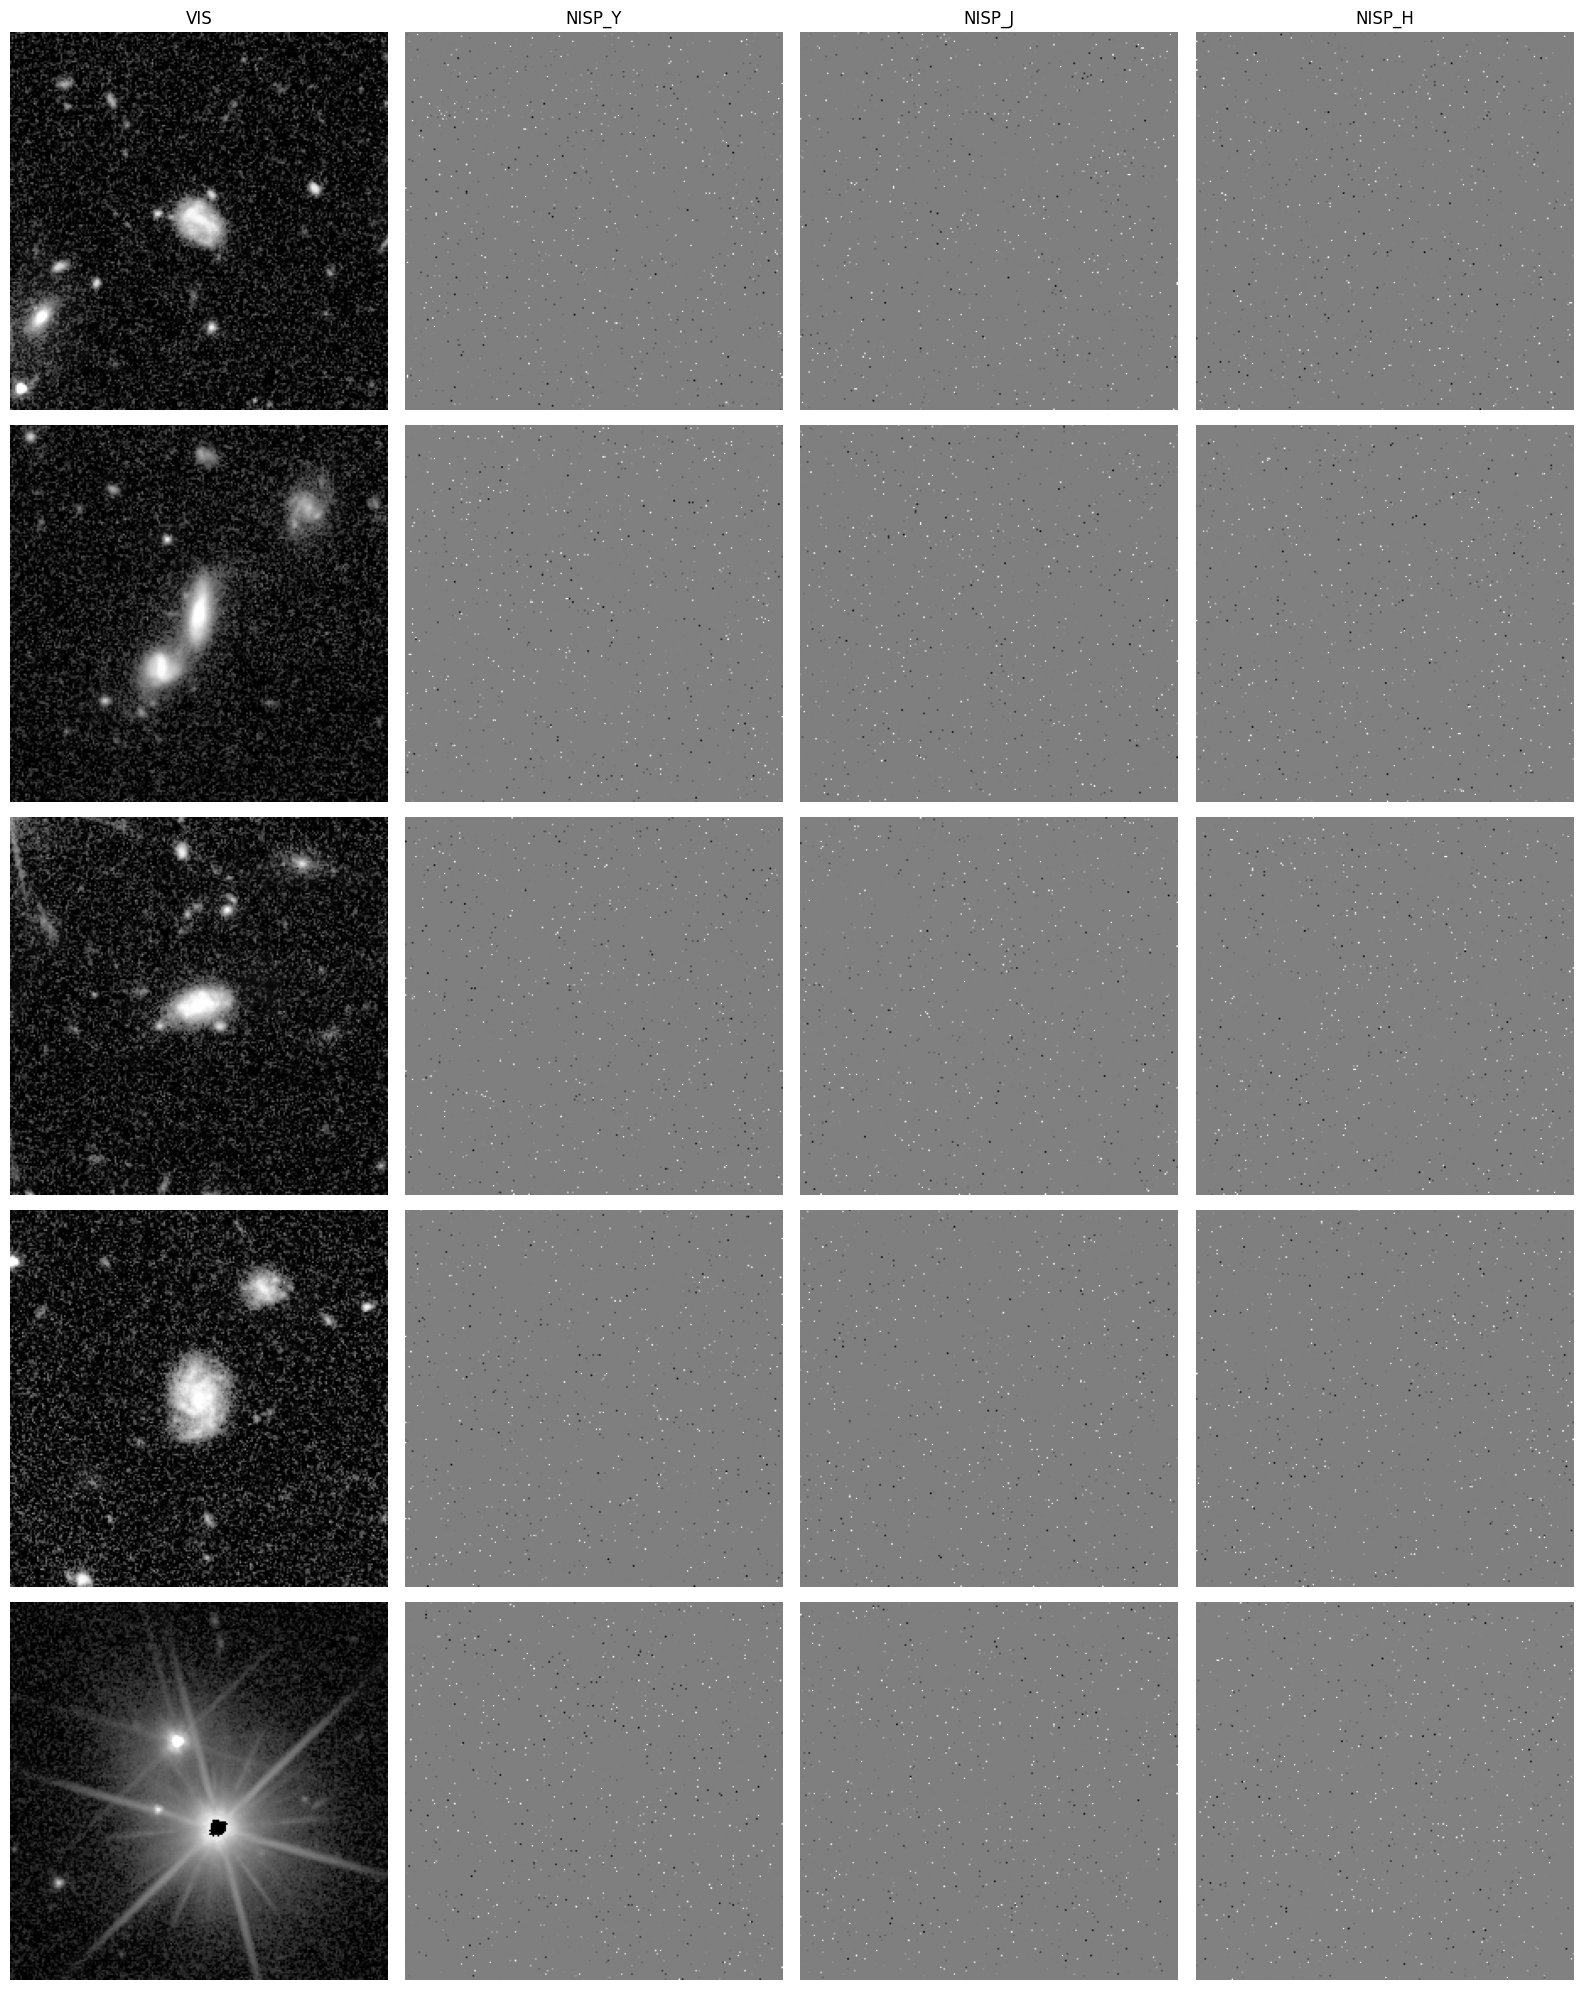

In [14]:
bands = ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image']
random.seed(42)
random_indices = random.sample(range(len(dataset_euclid)), 5)

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
for i, idx in enumerate(random_indices):
    sample = dataset_euclid[idx]
    for j, band in enumerate(bands):
        axes[i, j].imshow(np.array(sample[band]), cmap='gray')
        if i == 0:
            axes[i, j].set_title(band.replace('_image', ''))
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f'ID: {sample["object_id"]}', rotation=0, labelpad=50, va='center')
plt.tight_layout()
plt.show()

## 2. DESI Dataset

In [15]:
dataset_desi = load_dataset('arrow', data_files='../data/astroPT_desi_dataset/*.arrow', split='train')
print(f'Total samples: {len(dataset_desi)}')

sample = dataset_desi[0]
data = []
for key, value in sample.items():
    if hasattr(value, '__array__') or isinstance(value, (list, np.ndarray)):
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': str(np.array(value).shape)})
    else:
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': 'scalar'})

df = pd.DataFrame(data)
df

Total samples: 7856


,Column,Type,Shape
0,wavelength,list,"(3969,)"
1,flux,list,"(3969,)"
2,ivar,list,"(3969,)"
3,mask,list,"(3969,)"
4,targetid,int,scalar
5,redshift,float,scalar


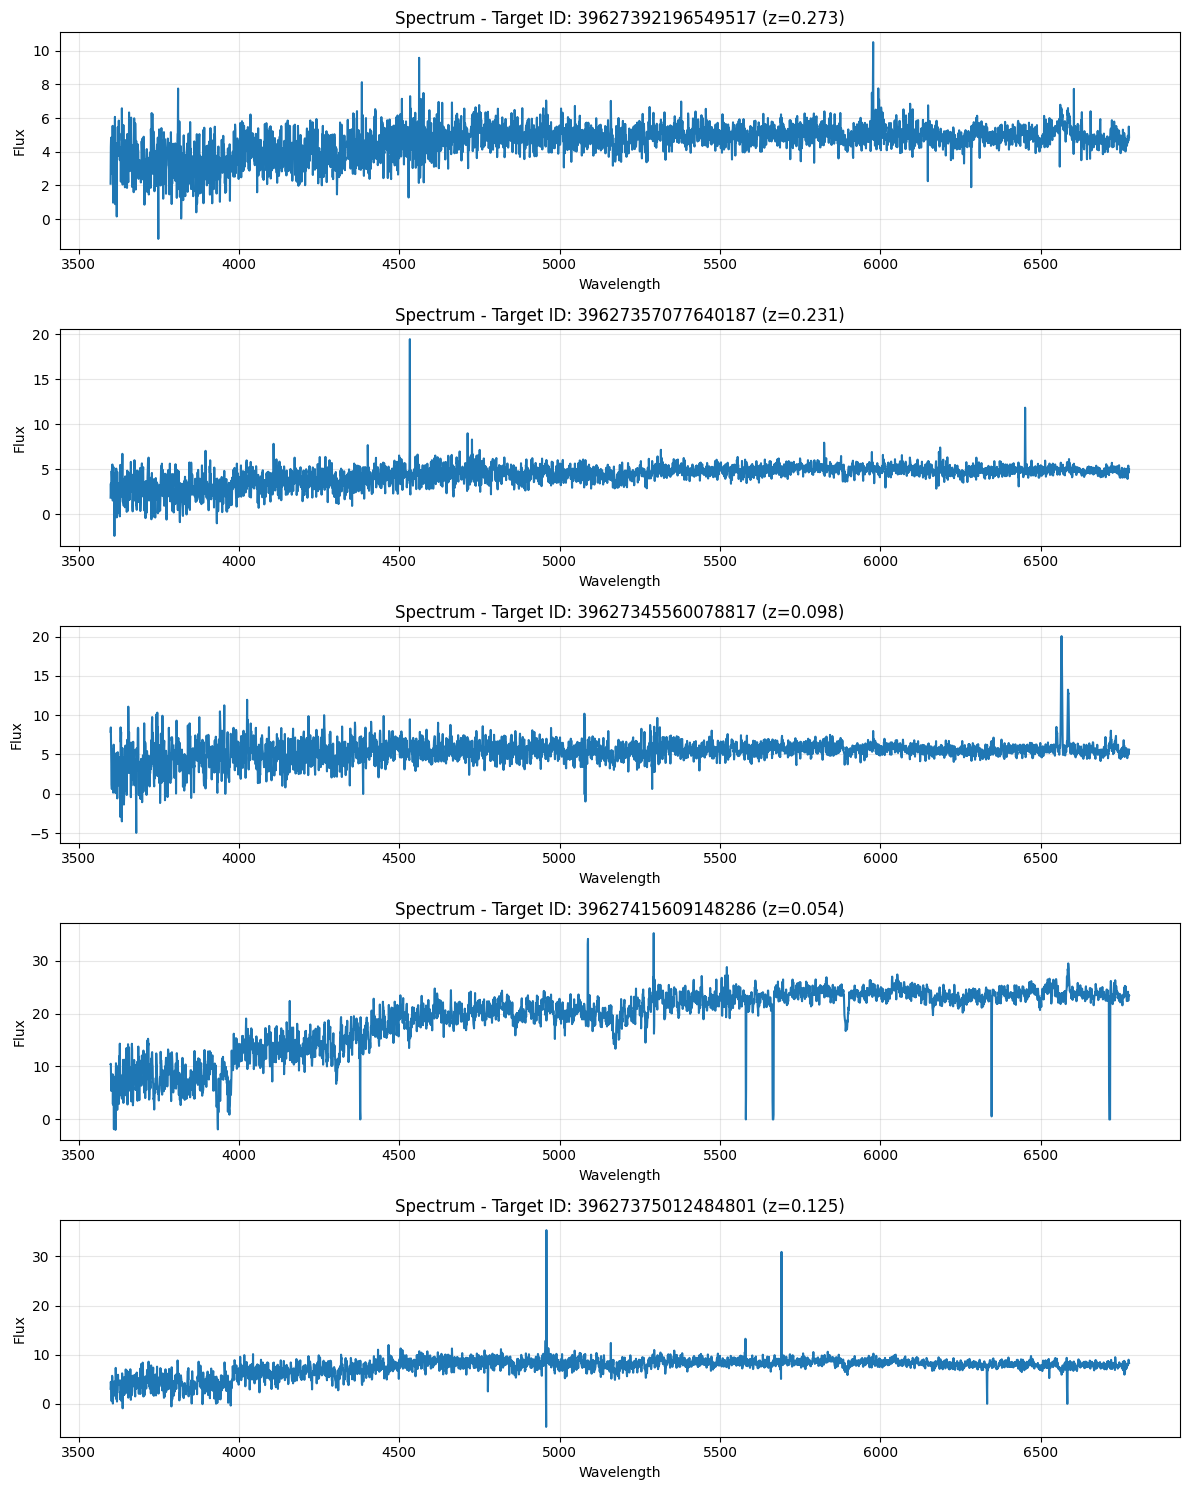

In [16]:
random.seed(42)
random_indices = random.sample(range(len(dataset_desi)), 5)

fig, axes = plt.subplots(5, 1, figsize=(12, 15))
for i, idx in enumerate(random_indices):
    sample = dataset_desi[idx]
    axes[i].plot(np.array(sample['wavelength']), np.array(sample['flux']))
    axes[i].set_xlabel('Wavelength')
    axes[i].set_ylabel('Flux')
    axes[i].set_title(f'Spectrum - Target ID: {sample["targetid"]} (z={sample["redshift"]:.3f})')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Euclid+DESI Dataset

In [17]:
dataset_euclid_desi = load_dataset('parquet', data_dir='../data/astroPT_euclid_desi_dataset/data', split='train')
print(f'Total samples: {len(dataset_euclid_desi)}')

sample = dataset_euclid_desi[0]
data = []
for key, value in sample.items():
    if isinstance(value, dict):
        data.append({'Column': key, 'Type': 'dict', 'Shape': f'{len(value)} keys'})
        for subkey, subvalue in value.items():
            if hasattr(subvalue, '__array__') or isinstance(subvalue, (list, np.ndarray)):
                data.append({'Column': f'  {key}.{subkey}', 'Type': type(subvalue).__name__, 'Shape': str(np.array(subvalue).shape)})
            else:
                data.append({'Column': f'  {key}.{subkey}', 'Type': type(subvalue).__name__, 'Shape': 'scalar'})
    elif hasattr(value, '__array__') or isinstance(value, (list, np.ndarray)):
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': str(np.array(value).shape)})
    else:
        data.append({'Column': key, 'Type': type(value).__name__, 'Shape': 'scalar'})

df = pd.DataFrame(data)
df

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/25 [00:00<?, ?it/s]

Total samples: 12210


,Column,Type,Shape
0,object_id,int,scalar
1,targetid,int,scalar
2,redshift,float,scalar
3,RGB_image,PngImageFile,scalar
4,VIS_image,list,"(224, 224)"
5,NISP_Y_image,list,"(224, 224)"
6,NISP_J_image,list,"(224, 224)"
7,NISP_H_image,list,"(224, 224)"
8,sed_data,dict,13 keys
9,sed_data.flux_g_ext_decam_1fwhm_aper,float,scalar


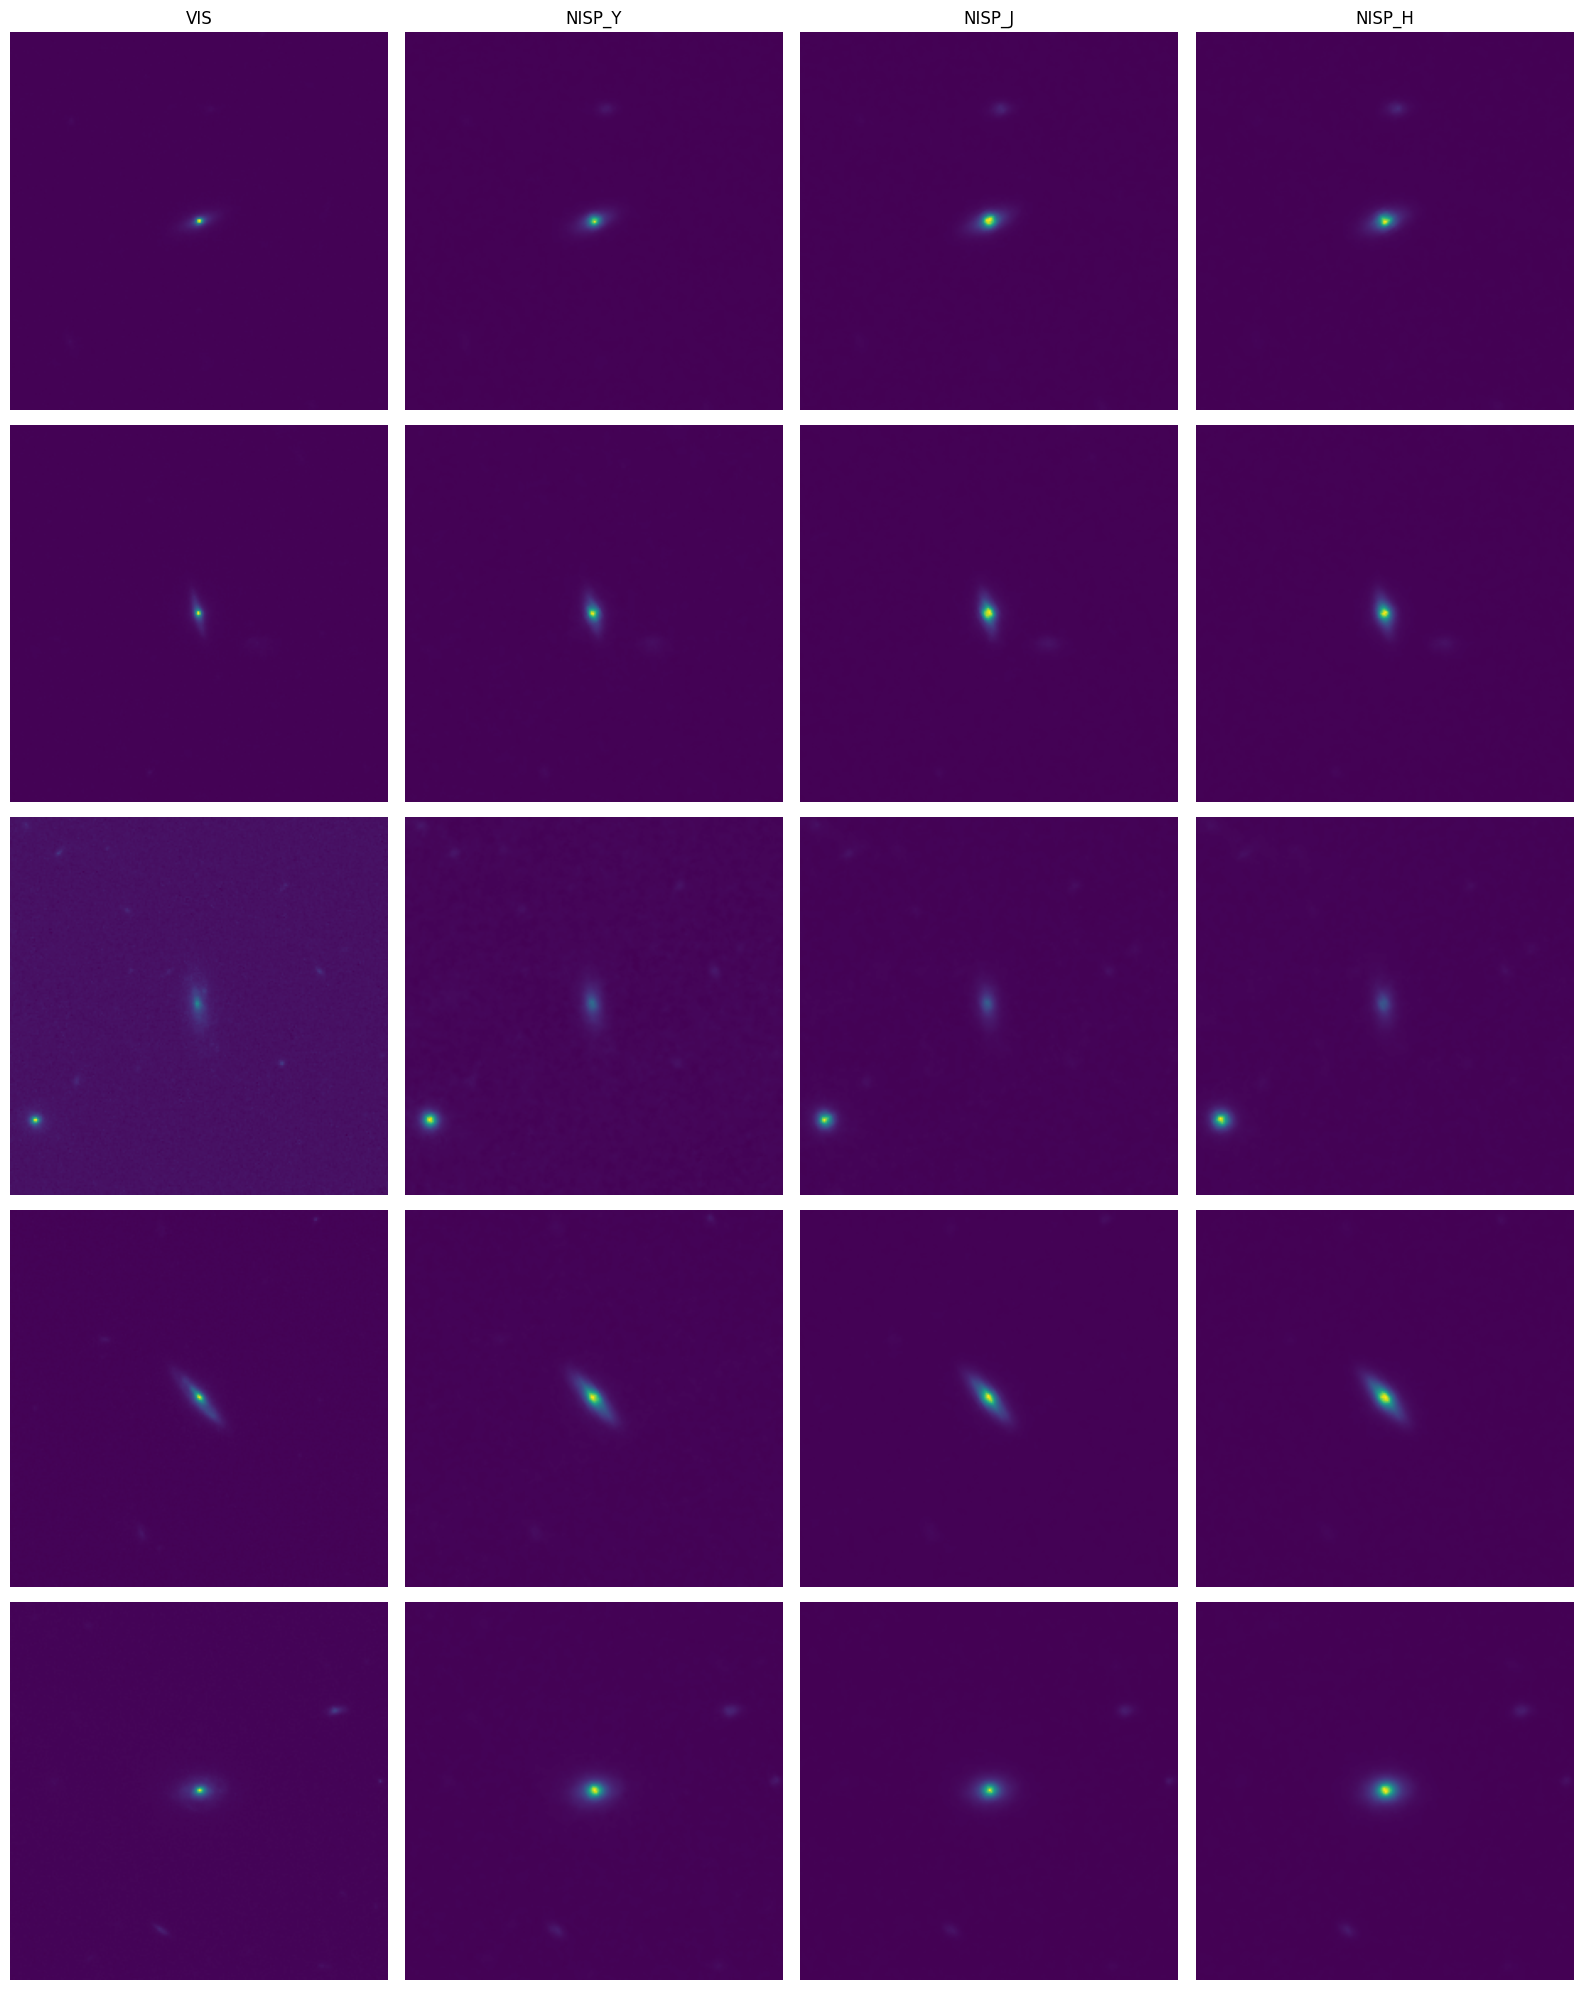

In [18]:
bands = ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image']
random.seed(412)
random_indices = random.sample(range(len(dataset_euclid_desi)), 5)

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
for i, idx in enumerate(random_indices):
    sample = dataset_euclid_desi[idx]
    for j, band in enumerate(bands):
        axes[i, j].imshow(np.array(sample[band]), cmap='viridis')
        if i == 0:
            axes[i, j].set_title(band.replace('_image', ''))
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f'ID: {sample["object_id"]}', rotation=0, labelpad=50, va='center')
plt.tight_layout()
plt.show()

## 4. HSC (Hyper Suprime-Cam) Dataset

In [62]:
dataset_hsc = load_dataset('MultimodalUniverse/hsc', split='train', streaming=True)

data = []
features = dataset_hsc.features

def parse_feature(key, feature):
    data = []
    if not isinstance(feature, dict):
        if hasattr(feature, 'feature'):
            feature = feature.feature
        shape = feature.shape if hasattr(feature, 'shape') else 'scalar'
        dtype = feature.dtype if hasattr(feature, 'dtype') else 'unknown'

        data.append({'Column': f'{key}', 'Type': dtype, 'Shape': shape})
    else:
        for sub_feature in feature:
            data.extend(parse_feature(sub_feature, feature[sub_feature]))
    return data

data = []
for feature in features:
    data.extend(parse_feature(feature, features[feature]))

df = pd.DataFrame(data)
df

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

,Column,Type,Shape
0,band,string,scalar
1,flux,float32,"(160, 160)"
2,ivar,float32,"(160, 160)"
3,mask,bool,"(160, 160)"
4,psf_fwhm,float32,scalar
5,scale,float32,scalar
6,a_g,float32,scalar
7,a_r,float32,scalar
8,a_i,float32,scalar
9,a_z,float32,scalar
